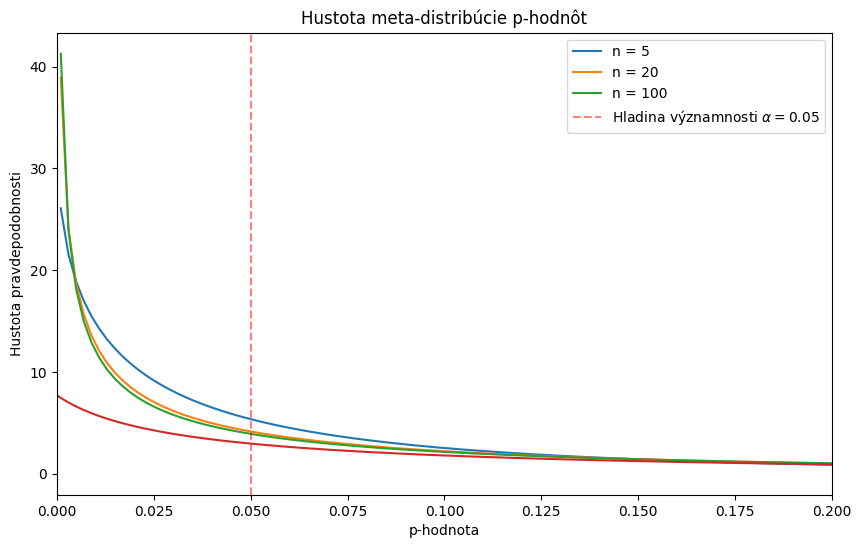

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, nct, norm

# hustota metadistribucie
def p_distribution_pdf(p, n, p_median):
    # stupne voľnosti pre t-rozdelenie
    df = n - 1
    ncp = t.ppf(1 - p_median, df)
    
    # premena p-hodnoty na t statistiku
    t_val = t.ppf(1 - p, df)
    
    pdf_t = nct.pdf(t_val, df, ncp)
    
    dt_dp = 1 / t.pdf(t_val, df)
    
    return pdf_t * dt_dp

# rozsah p-hodnot
p_range = np.linspace(0.001, 0.99, 500)
n_values = [5, 20, 100]
p_med = 0.05

plt.figure(figsize=(10, 6))
for n in n_values:
    pdf_vals = [p_distribution_pdf(p, n, p_med) for p in p_range]
    plt.plot(p_range, pdf_vals, label=f'n = {n}')

plt.title(f'Hustota meta-distribúcie p-hodnôt')
plt.xlabel('p-hodnota')
plt.ylabel('Hustota pravdepodobnosti')

plt.axvline(0.05, color='red', linestyle='--', alpha=0.5, label=r'Hladina významnosti $\alpha = 0.05$')
plt.legend()
plt.grid(False)
plt.xlim(0, 0.2)   # rozsah osi x (napr. len malé p-hodnoty)
plt.plot(p_range - 0.02, pdf_vals)
plt.savefig("metadistribucia", dpi=300)
plt.show()
